<a href="https://colab.research.google.com/github/cailuj/TCC/blob/main/fase_3_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Configuração do Ambiente e Importações

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
from sklearn.model_selection import GroupShuffleSplit
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/MINI-DDSM/'
EXCEL_PATH = os.path.join(BASE_PATH, 'DataWMask.xlsx')
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
SEED = 42

Mounted at /content/drive


### 2. Carregamento dos Dados e Divisão em Treino/Val/Teste

In [ ]:
df = pd.read_excel(EXCEL_PATH)

df['fullPath'] = df['fullPath'].str.replace('\\', '/', regex=False)
df['Tumour_Contour'] = df['Tumour_Contour'].str.replace('\\', '/', regex=False)

def extract_patient_id(path):
    parts = path.split('/')
    return parts[1] if len(parts) > 1 else 'unknown'

df['patient_id'] = df['fullPath'].apply(extract_patient_id)

class_map = {'Normal': 0, 'Benign': 1, 'Cancer': 2}
df['label'] = df['Status'].map(class_map)

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['patient_id']))

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['patient_id']))

train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print(f'Treino: {len(train_df)} | Val: {len(val_df)} | Teste: {len(test_df)}')

Treino: 4968 | Val: 1236 | Teste: 1604


### 3. Definição do Pipeline de Pré-processamento (tf.data)

In [ ]:
def load_and_preprocess(path, label):
    full_path = tf.strings.join([BASE_PATH, path])
    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def create_ds(dataframe, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['fullPath'].values, dataframe['label'].values))
    if shuffle:
        ds = ds.shuffle(len(dataframe))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(train_df)
val_ds = create_ds(val_df, shuffle=False)
test_ds = create_ds(test_df, shuffle=False)

### 4. Definição do Modelo VGG16 e Treinamento

In [ ]:
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='swish'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 525s 3s/step - accuracy: 0.3525 - loss: 1.1608 - val_accuracy: 0.3301 - val_loss: 1.1169
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.3474 - loss: 1.1278 - val_accuracy: 0.3301 - val_loss: 1.0987
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - accuracy: 0.3440 - loss: 1.1198 - val_accuracy: 0.3204 - val_loss: 1.0918
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.3454 - loss: 1.1149 - val_accuracy: 0.3325 - val_loss: 1.0883
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.3555 - loss: 1.1059 - val_accuracy: 0.3374 - val_loss: 1.0852
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.3504 - loss: 1.1087 - val_accuracy: 0.3350 - val_loss: 1.0824
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.3714 - loss: 1.1021 - val_accuracy: 0.3503 - val_loss: 1.0791
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━

### 5. Avaliação de Performance e Matriz de Confusão

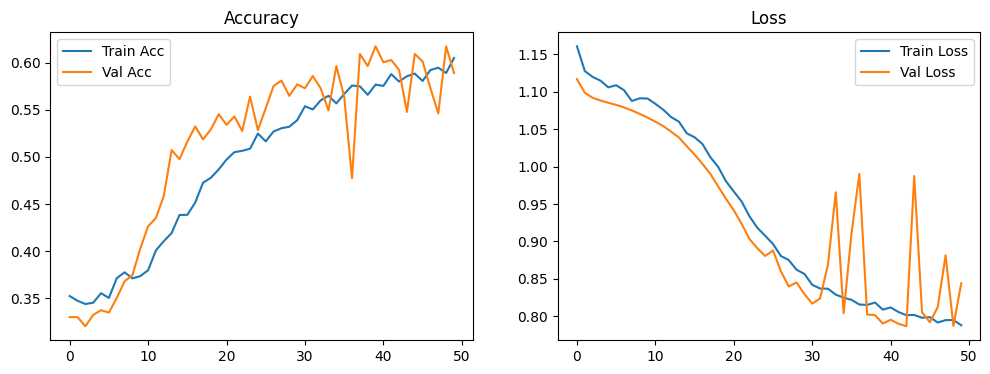

51/51 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.6166 - loss: 0.7702

Acurácia no Teste (Holdout): 0.6166

Calculando métricas detalhadas...
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       0.64      0.92      0.76       588
      Benign       0.61      0.40      0.48       516
      Cancer       0.58      0.48      0.53       500

    accuracy                           0.62      1604
   macro avg       0.61      0.60      0.59      1604
weighted avg       0.61      0.62      0.60      1604



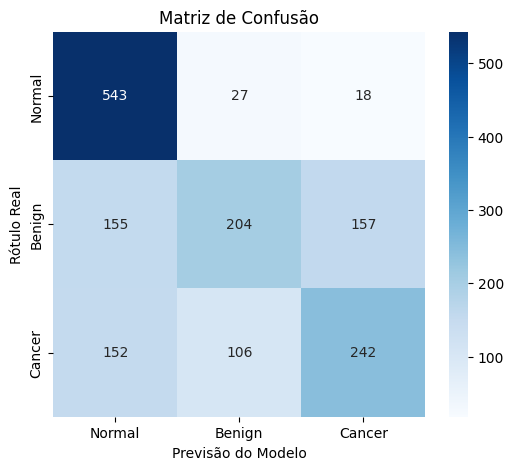

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

test_loss, test_acc = model.evaluate(test_ds)
print(f'\nAcurácia no Teste (Holdout): {test_acc:.4f}')

print("\nCalculando métricas detalhadas...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nRelatório de Classificação:")
target_names = ['Normal', 'Benign', 'Cancer']
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Real')
plt.xlabel('Previsão do Modelo')
plt.show()

### 6. Explicabilidade: Grad-CAM++

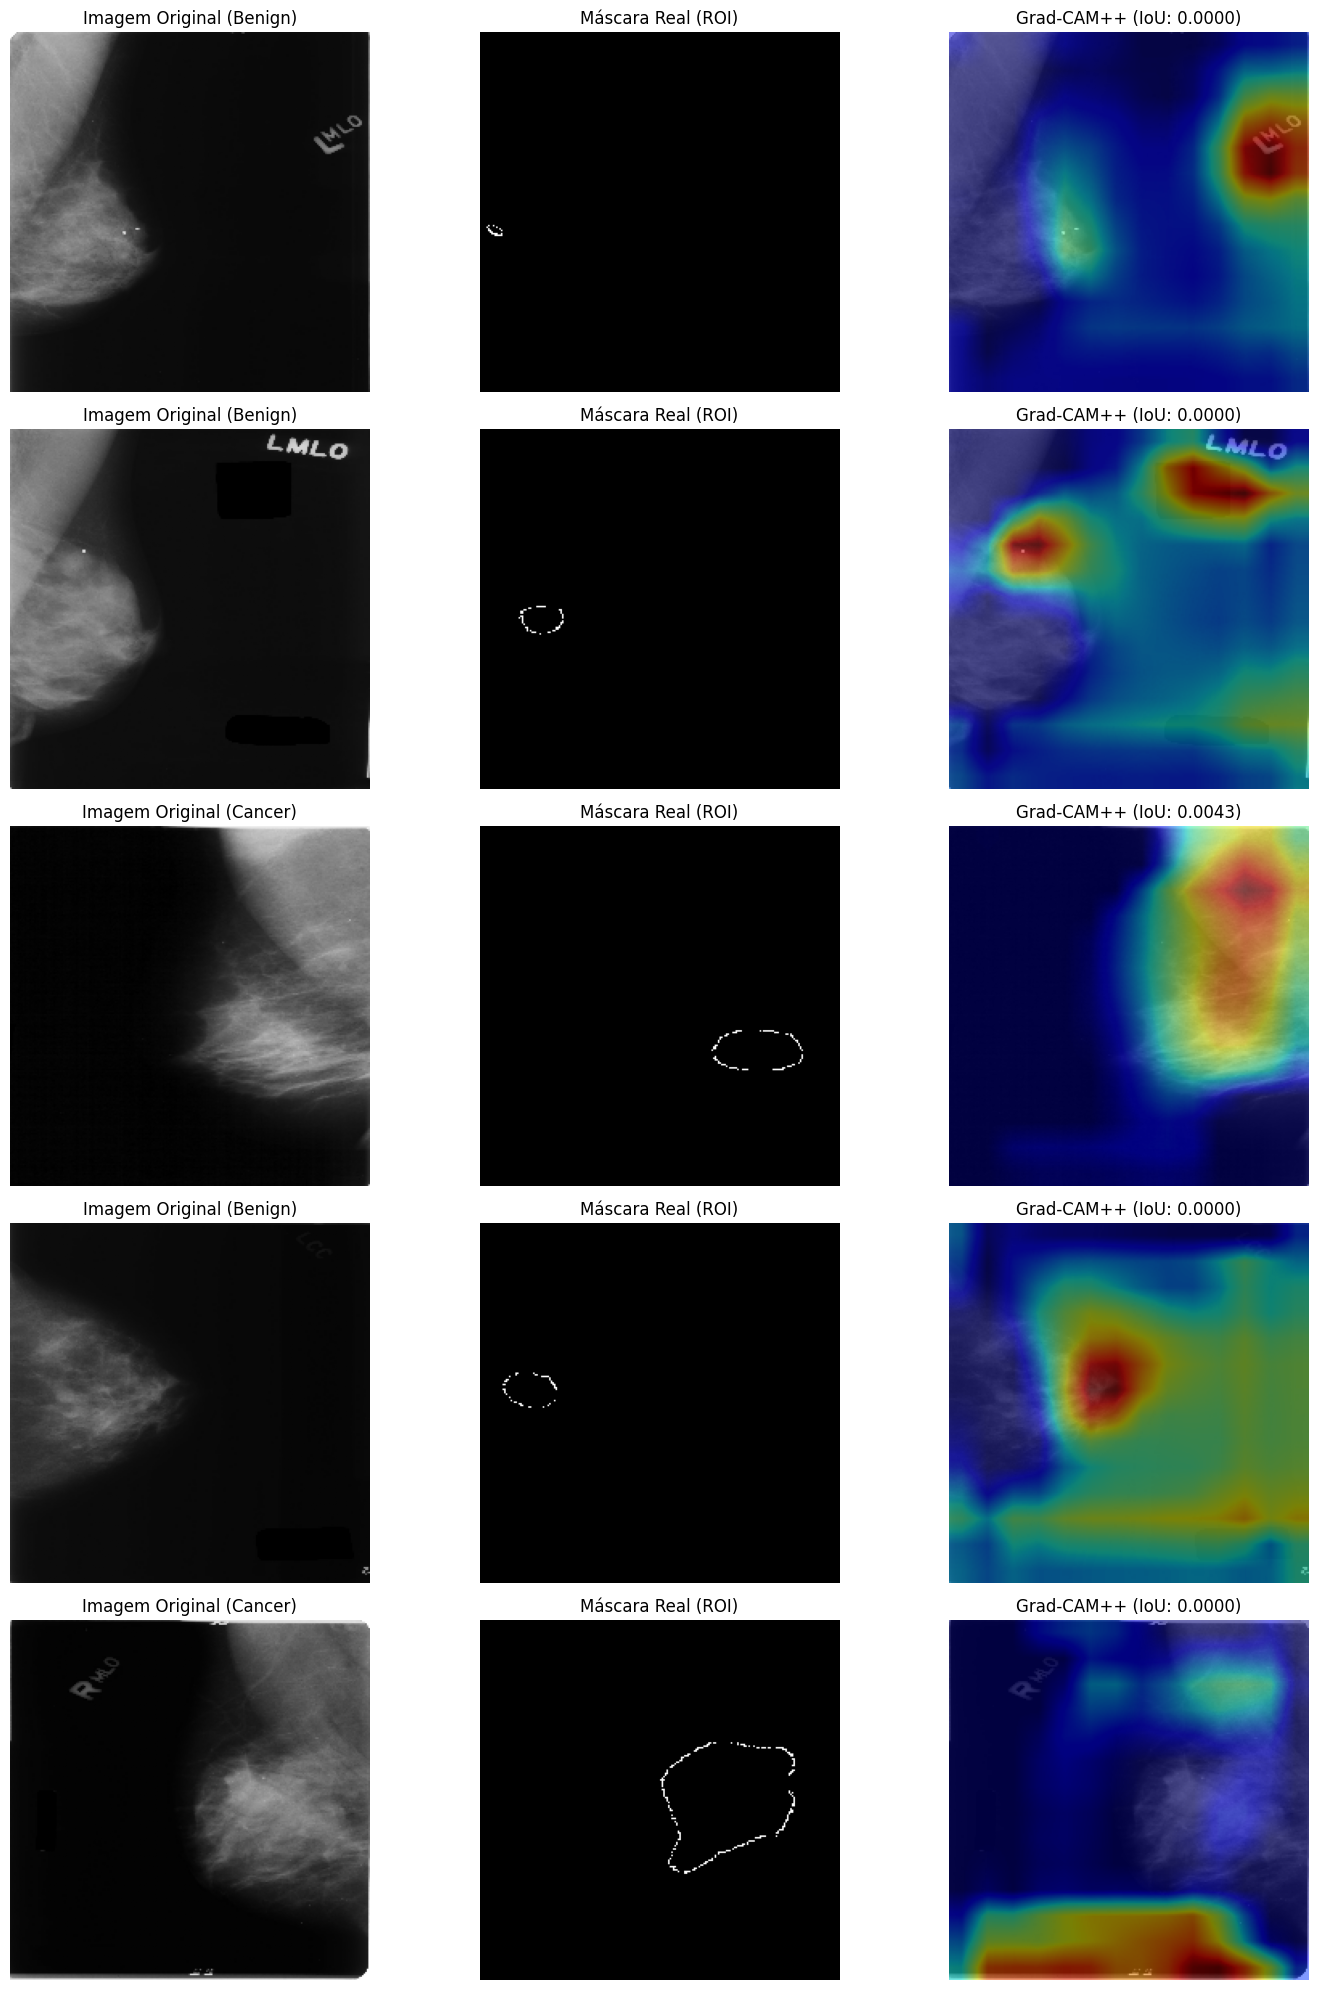

In [ ]:
import cv2
import numpy as np

def get_gradcam_plus_plus(model, img_array, last_conv_layer_name):
    # Obtém o modelo base dinamicamente (VGG16)
    base_model = model.layers[0]
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    res_output = last_conv_layer.output

    x = model.layers[1](base_model.output)
    for layer in model.layers[2:]:
        x = layer(x)

    grad_model = tf.keras.models.Model([base_model.input], [res_output, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(tf.multiply(weights, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
    return heatmap[0]

def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 0
    return np.sum(intersection) / np.sum(union)

test_with_masks = test_df[(test_df['Status'] != 'Normal') & (test_df['Tumour_Contour'] != '-')]

if len(test_with_masks) >= 5:
    sample_rows = test_with_masks.sample(5, random_state=SEED)

    fig, axes = plt.subplots(5, 3, figsize=(15, 20))

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = os.path.join(BASE_PATH, row['fullPath'])
        mask_path = os.path.join(BASE_PATH, row['Tumour_Contour'])

        img_raw = tf.io.read_file(img_path)
        img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
        img_resized = tf.image.resize(img_decoded, IMG_SIZE)
        img_normalized = tf.cast(img_resized, tf.float32) / 255.0
        img_batch = tf.expand_dims(img_normalized, 0)

        try:
            heatmap = get_gradcam_plus_plus(model, img_batch, 'block5_conv3')

            mask_img = cv2.imread(mask_path, 0)
            if mask_img is not None:
                mask = cv2.resize(mask_img, IMG_SIZE) > 0
                heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
                heatmap_bin = heatmap_resized > 0.5
                iou_score = calculate_iou(mask, heatmap_bin)

                axes[i, 0].imshow(img_normalized)
                axes[i, 0].set_title(f'Imagem Original ({row["Status"]})')
                axes[i, 0].axis('off')

                axes[i, 1].imshow(mask, cmap='gray')
                axes[i, 1].set_title('Máscara Real (ROI)')
                axes[i, 1].axis('off')

                axes[i, 2].imshow(img_normalized)
                axes[i, 2].imshow(heatmap_resized, alpha=0.5, cmap='jet')
                axes[i, 2].set_title(f'Grad-CAM++ (IoU: {iou_score:.4f})')
                axes[i, 2].axis('off')
            else:
                print(f'Erro ao carregar o arquivo de máscara para a amostra {i+1}.')
        except Exception as e:
            print(f'Erro na execução do Grad-CAM++ para a amostra {i+1}: {e}')

    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma amostra com máscara encontrada no conjunto de teste.')

### 7. Preparação de Amostras para LIME e SHAP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

sample_df = test_df[(test_df['Status'] != 'Normal') & (test_df['Tumour_Contour'] != '-')].sample(5, random_state=SEED)

sample_images = []
sample_labels = []
sample_masks = []

for _, row in sample_df.iterrows():
    img_path = os.path.join(BASE_PATH, row['fullPath'])
    img_raw = tf.io.read_file(img_path)
    img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
    img_resized = tf.image.resize(img_decoded, IMG_SIZE)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0
    sample_images.append(img_normalized.numpy())
    sample_labels.append(row['label'])

    mask_path = os.path.join(BASE_PATH, row['Tumour_Contour'])
    mask_raw = cv2.imread(mask_path, 0)
    if mask_raw is not None:
        mask_resized = cv2.resize(mask_raw, IMG_SIZE)
    else:
        mask_resized = np.zeros(IMG_SIZE)
    sample_masks.append(mask_resized)

sample_images = np.array(sample_images)
sample_labels = np.array(sample_labels)
sample_masks = np.array(sample_masks)
print(f'Selecionadas {len(sample_images)} imagens com máscaras para explicação.')

Selecionadas 5 imagens com máscaras para explicação.


### 8. Explicabilidade: LIME

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3dd1d964e6e435dde12041a4b4e27c1135770ab7875d1d302e8fab86060521e3
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

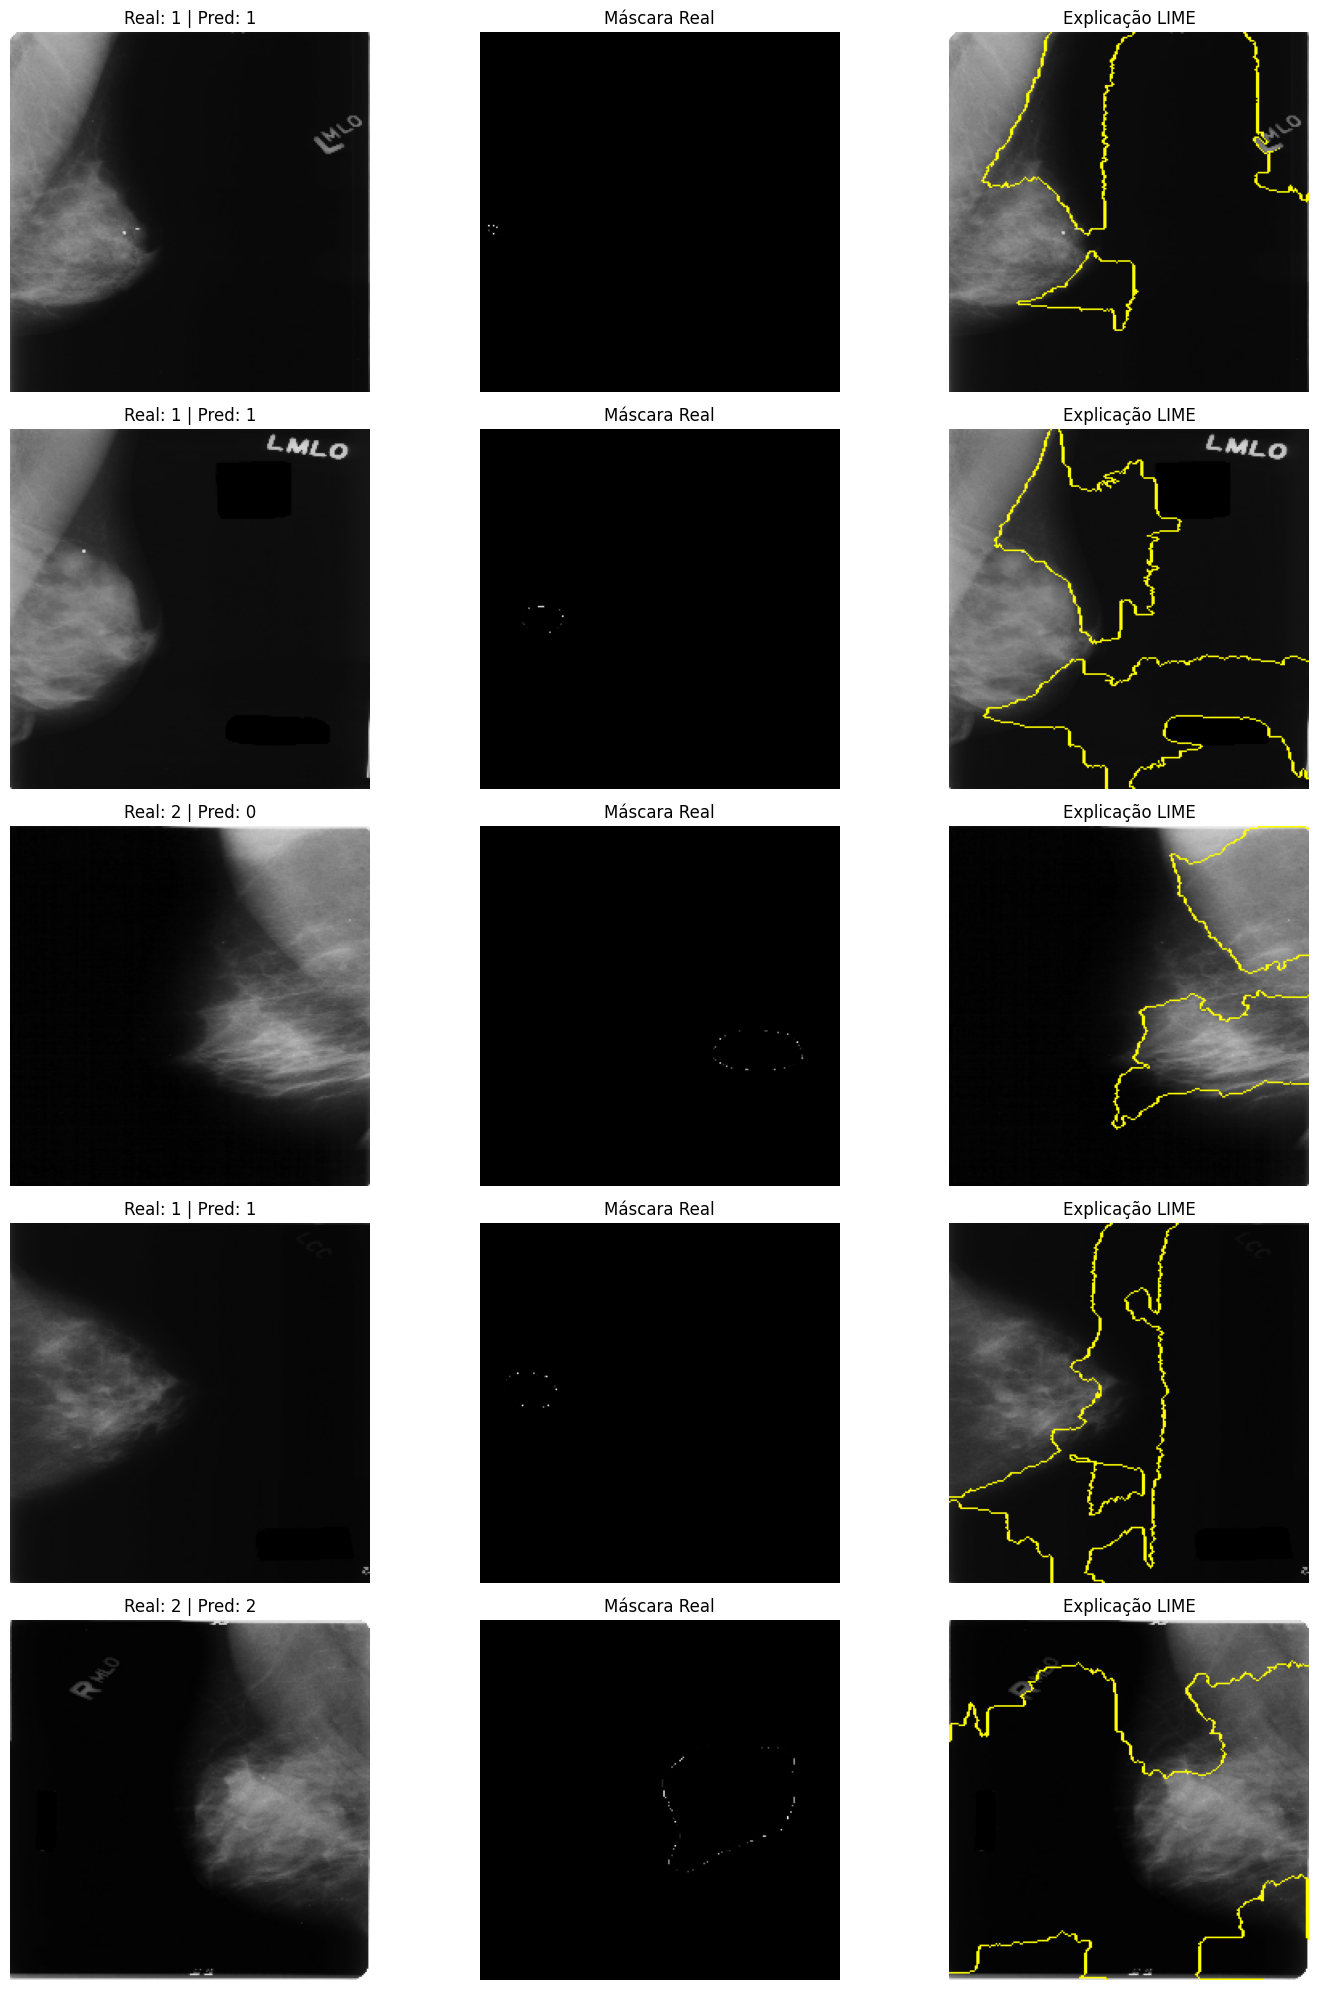

In [ ]:
!pip install lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    img = sample_images[i]
    label = sample_labels[i]
    mask_img = sample_masks[i]

    explanation = explainer.explain_instance(
        img.astype('double'),
        model.predict,
        top_labels=3,
        hide_color=0,
        num_samples=500
    )

    preds = model.predict(np.expand_dims(img, axis=0))
    pred_class = np.argmax(preds)

    temp, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Real: {label} | Pred: {pred_class}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_img, cmap='gray')
    axes[i, 1].set_title('Máscara Real')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mark_boundaries(temp, mask))
    axes[i, 2].set_title('Explicação LIME')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### 9. Explicabilidade: SHAP

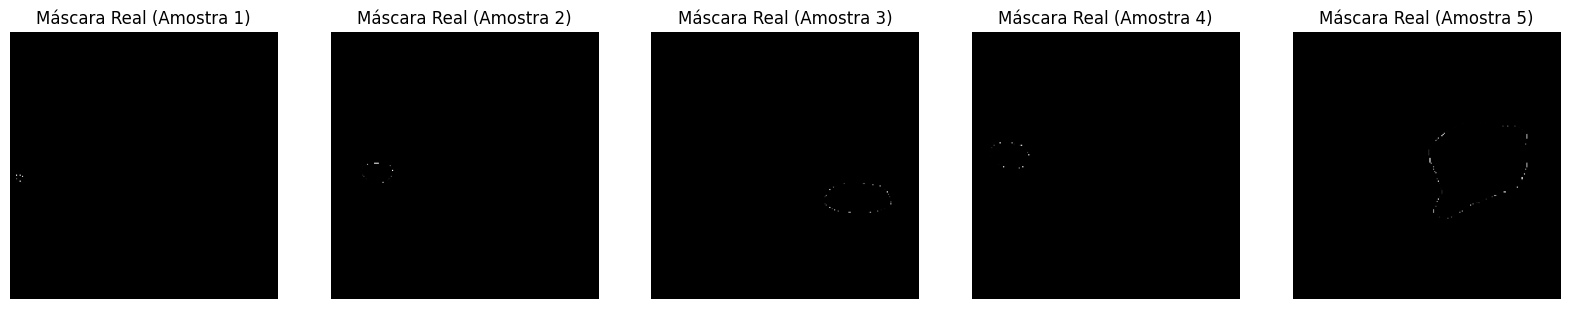

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_19
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


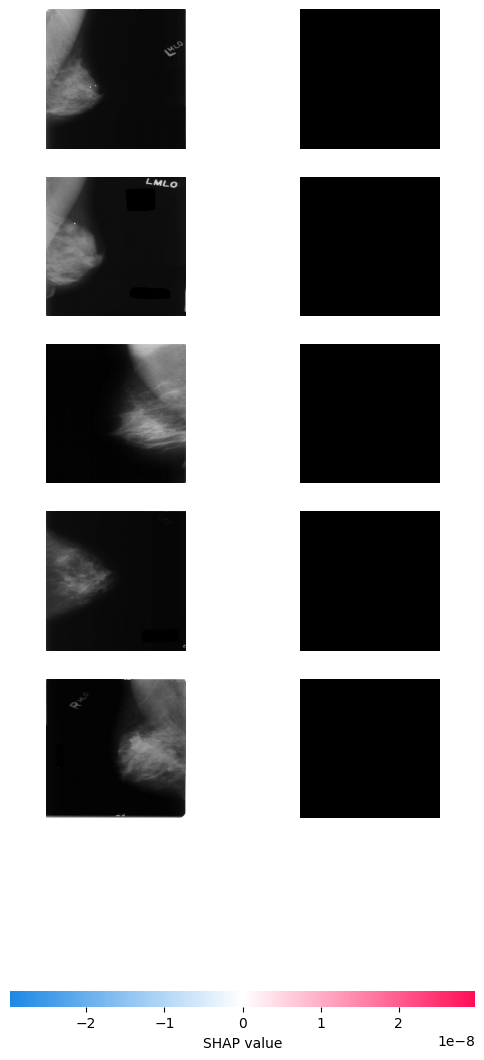

In [ ]:
import shap
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(sample_masks[i], cmap='gray')
    axes[i].set_title(f'Máscara Real (Amostra {i+1})')
    axes[i].axis('off')
plt.show()

explainer_shap = shap.GradientExplainer(model, sample_images)

shap_values = explainer_shap.shap_values(sample_images)

shap.image_plot(shap_values, sample_images)